# Chapter 4: Lie Groups and Lie Algebras

**Source Span.** `An Introduction to Manifolds.pdf`, printed pages `164-189` (PDF pages `183-208`). The mathematical content used here is the Lie group and Lie algebra material through printed page `188`; printed page `189` begins the next chapter and was inspected only to confirm the boundary.

**Chapter goal.** Turn the chapter's local story into executable objects: a Lie group is a smooth manifold whose multiplication and inverse are smooth; a matrix Lie group is often visible as a level set or a closed subgroup; the matrix exponential gives curves with prescribed initial velocity; and the tangent space at the identity becomes a Lie algebra through left-invariant vector fields.

This notebook uses the source for orientation, terminology, and coverage only. The prose, examples, diagrams, code, and checks below are original teaching material. The recurring inspection question is: **what property at the identity controls the nearby group geometry?**


## Visual Storyboard

### Chapter Implementation Brief

**Chapter goal.** Explain how smooth group operations concentrate local information at the identity, and how the bracket on left-invariant vector fields becomes the matrix commutator for classical matrix groups.

**Source Span read.** Printed pages `164-189` from PDF pages `183-208`. The chapter content inspected covers Lie groups, matrix group examples, Lie subgroups, closed subgroup theorem, irrational lines in a torus, matrix exponential, trace, `det(exp X)=exp(tr X)`, the determinant differential, tangent spaces for `GL`, `SL`, and `O`, left-invariant vector fields, Lie algebras, the commutator bracket, pushforwards, Lie algebra homomorphisms, adjoint representation, and parallelizability themes.

**Concept inventory.** Smooth multiplication and inverse; left and right translations; matrix groups as open sets or level sets; the importance of choosing the smallest natural target, such as symmetric matrices for `A.T A`; embedded versus immersed Lie subgroups; dense irrational line in a torus; matrix exponential as a nonsingular curve factory; trace invariance; determinant differential; tangent constraints `tr X = 0` and `X.T + X = 0`; left-invariant field transport; bracket closure; homomorphism differentials; adjoint and global frames.

**Library routing.** NetworkX and Matplotlib produce the storyboard/proof graph; Plotly and SciPy expose the `SO(2)` exponential orbit; SymPy checks exact determinant differentials; NumPy and SciPy run matrix exponentials and commutators; Matplotlib records durable PNG diagrams; CSV/JSON artifacts store invariant data.

**Visual sequence.** `storyboard-lie-algebra-flow.png`, `torus-irrational-line-subgroup.png`, `so2-exponential-orbit.html`, `det-trace-exponential-check.png`, `tangent-conditions-sl-o.png`, `bracket-commutator-table.png`, `left-invariant-field-transport.png`, `homomorphism-differential-square.png`, and `sl2-tangent-lab.png`.

**Computational checks.** Artifact existence and nonzero size; `SO(2)` orthogonality and determinant residuals; symbolic `d/dt det(I+tX)|0 = tr(X)`; numeric `det(exp X)=exp(tr X)` residuals; tangent residuals for `SL` and `O`; Jacobi identity and closure for commutators; left-invariance residual; determinant and inner-automorphism homomorphism residuals.

**Proof-visualization strategy.** Use a dependency graph for chapter flow, exact symbolic differentials for the determinant proof move, residual heatmaps for tangent-space constraints, a commutative square for homomorphism differentials, and perturbation plots for failure modes.


## Library Routing

This chapter includes a chapter-specific library routing table in the storyboard and generated CSV artifacts. The routing choices favor symbolic matrix/form checks for exact identities, Matplotlib for durable diagrams, Plotly where an interactive inspection target clarifies a geometric family, and JSON/CSV ledgers for reproducible invariants.

In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display
from scipy.linalg import expm

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate the An Introduction to Manifolds course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

UNIT_KEY = "chapter-04-lie-groups-and-lie-algebras"
UNIT_TITLE = "Lie Groups and Lie Algebras"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

rng = np.random.default_rng(427704)
all_artifacts = []
check_registry = {}


def register(path):
    all_artifacts.append(Path(path))
    return Path(path)


def commutator(A, B):
    return A @ B - B @ A


def rows_to_markdown(rows, columns):
    header = "| " + " | ".join(columns) + " |"
    sep = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = ["| " + " | ".join(str(row[col]) for col in columns) + " |" for row in rows]
    return "\n".join([header, sep, *body])

print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT}")


Book root: D:\Geometry\An-Introduction-to-Manifolds
Artifact root: D:\Geometry\An-Introduction-to-Manifolds\artifacts\chapter-04-lie-groups-and-lie-algebras


## Computational Translation Guide

| Book language | Computational object | Inspection target |
| --- | --- | --- |
| Lie group | A set of matrices plus smooth operations | Does multiplication/inverse stay in the set? |
| Lie subgroup | Constraint set or immersed image | Is it embedded, merely immersed, closed, or dense? |
| Matrix exponential | A curve `t -> exp(tX)` | Does it stay nonsingular, and what is its initial velocity? |
| Trace and determinant | Scalar invariants of matrices | Does `det(exp X)` equal `exp(tr X)`? |
| Tangent space at identity | Linearized constraint | Is `tr X = 0` or `X.T + X = 0`? |
| Left-invariant field | Transport of one tangent vector by left multiplication | Is the field value at `g` determined by the value at `e`? |
| Lie bracket | Commutator of matrices for `gl(n,R)` | Does the bracket close and satisfy Jacobi? |
| Homomorphism differential | Linear map between tangent spaces | Does it preserve brackets? |


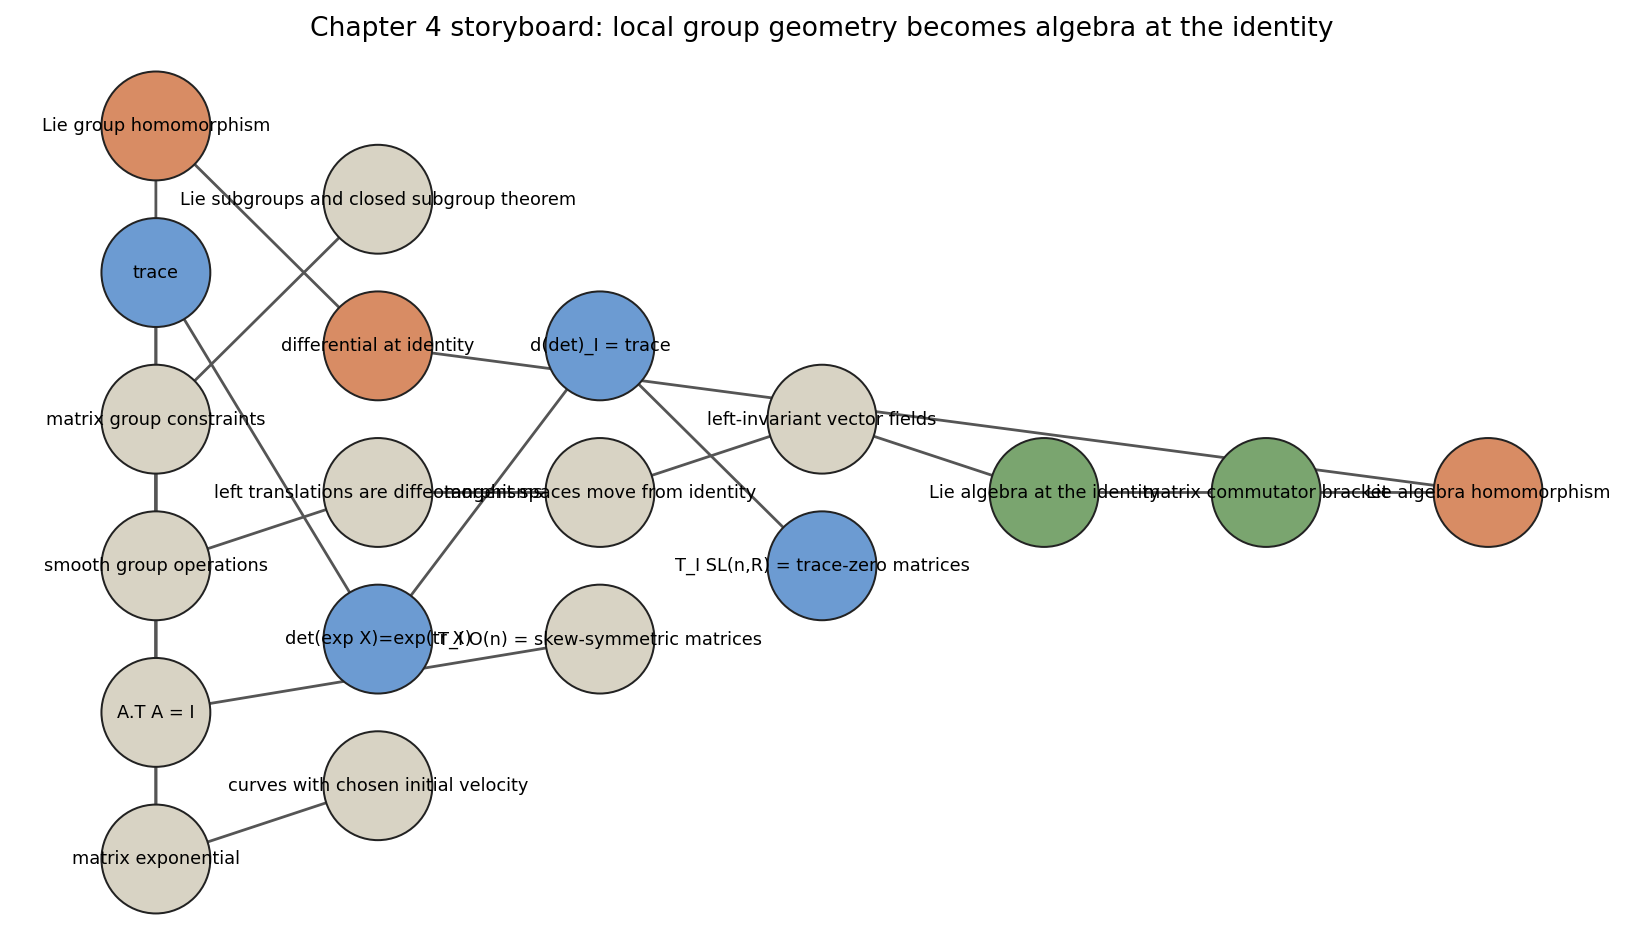

| concept | library | artifact | validation |
| --- | --- | --- | --- |
| storyboard | NetworkX + Matplotlib | storyboard-lie-algebra-flow.png | directed graph is weakly connected |
| SO(2) exponential | Plotly + SciPy | so2-exponential-orbit.html | orthogonality and determinant residuals |
| determinant and trace | SymPy + SciPy | det-trace-exponential-check.png | symbolic differential and numeric exponential identity |
| tangent constraints | SymPy + Matplotlib | tangent-conditions-sl-o.png | trace-zero and skew residuals |
| commutator bracket | NumPy + Matplotlib | bracket-commutator-table.png | Jacobi residual and closure |
| left-invariant transport | NumPy + Matplotlib | left-invariant-field-transport.png | l_g* X_h = X_gh residual |
| homomorphism differential | NetworkX + NumPy | homomorphism-differential-square.png | bracket preservation residuals |

In [2]:
flow_edges = [
    ("smooth group operations", "matrix group constraints"),
    ("smooth group operations", "matrix exponential"),
    ("smooth group operations", "Lie group homomorphism"),
    ("matrix exponential", "trace"),
    ("matrix group constraints", "A.T A = I"),
    ("smooth group operations", "left translations are diffeomorphisms"),
    ("left translations are diffeomorphisms", "tangent spaces move from identity"),
    ("matrix group constraints", "Lie subgroups and closed subgroup theorem"),
    ("matrix exponential", "curves with chosen initial velocity"),
    ("trace", "det(exp X)=exp(tr X)"),
    ("det(exp X)=exp(tr X)", "d(det)_I = trace"),
    ("d(det)_I = trace", "T_I SL(n,R) = trace-zero matrices"),
    ("A.T A = I", "T_I O(n) = skew-symmetric matrices"),
    ("tangent spaces move from identity", "left-invariant vector fields"),
    ("left-invariant vector fields", "Lie algebra at the identity"),
    ("Lie algebra at the identity", "matrix commutator bracket"),
    ("Lie group homomorphism", "differential at identity"),
    ("differential at identity", "Lie algebra homomorphism"),
    ("matrix commutator bracket", "Lie algebra homomorphism"),
]
flow = nx.DiGraph(flow_edges)
layers = {
    "smooth group operations": 0,
    "matrix group constraints": 0,
    "matrix exponential": 0,
    "trace": 0,
    "A.T A = I": 0,
    "Lie group homomorphism": 0,
    "left translations are diffeomorphisms": 1,
    "curves with chosen initial velocity": 1,
    "det(exp X)=exp(tr X)": 1,
    "Lie subgroups and closed subgroup theorem": 1,
    "differential at identity": 1,
    "tangent spaces move from identity": 2,
    "d(det)_I = trace": 2,
    "T_I O(n) = skew-symmetric matrices": 2,
    "left-invariant vector fields": 3,
    "T_I SL(n,R) = trace-zero matrices": 3,
    "Lie algebra at the identity": 4,
    "matrix commutator bracket": 5,
    "Lie algebra homomorphism": 6,
}
for node in flow.nodes:
    flow.nodes[node]["layer"] = layers.get(node, 0)
pos = nx.multipartite_layout(flow, subset_key="layer")

fig, ax = plt.subplots(figsize=(13, 7.2))
node_colors = []
for node in flow.nodes:
    if "homomorphism" in node or "differential" in node:
        node_colors.append("#d88c64")
    elif "trace" in node or "det" in node:
        node_colors.append("#6c9bd2")
    elif "Lie algebra" in node or "commutator" in node:
        node_colors.append("#7aa56f")
    else:
        node_colors.append("#d8d3c4")
nx.draw_networkx_edges(flow, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=15, width=1.25, edge_color="#555555")
nx.draw_networkx_nodes(flow, pos, ax=ax, node_color=node_colors, node_size=2400, edgecolors="#222222", linewidths=0.9)
nx.draw_networkx_labels(flow, pos, ax=ax, font_size=8)
ax.set_title("Chapter 4 storyboard: local group geometry becomes algebra at the identity")
ax.axis("off")
storyboard_path = register(save_matplotlib(fig, FIGURES / "storyboard-lie-algebra-flow.png"))
plt.close(fig)

routing_rows = [
    {"concept": "storyboard", "library": "NetworkX + Matplotlib", "artifact": "storyboard-lie-algebra-flow.png", "validation": "directed graph is weakly connected"},
    {"concept": "SO(2) exponential", "library": "Plotly + SciPy", "artifact": "so2-exponential-orbit.html", "validation": "orthogonality and determinant residuals"},
    {"concept": "determinant and trace", "library": "SymPy + SciPy", "artifact": "det-trace-exponential-check.png", "validation": "symbolic differential and numeric exponential identity"},
    {"concept": "tangent constraints", "library": "SymPy + Matplotlib", "artifact": "tangent-conditions-sl-o.png", "validation": "trace-zero and skew residuals"},
    {"concept": "commutator bracket", "library": "NumPy + Matplotlib", "artifact": "bracket-commutator-table.png", "validation": "Jacobi residual and closure"},
    {"concept": "left-invariant transport", "library": "NumPy + Matplotlib", "artifact": "left-invariant-field-transport.png", "validation": "l_g* X_h = X_gh residual"},
    {"concept": "homomorphism differential", "library": "NetworkX + NumPy", "artifact": "homomorphism-differential-square.png", "validation": "bracket preservation residuals"},
]
routing_path = register(save_csv(routing_rows, TABLES / "chapter-04-library-routing.csv"))
storyboard_check_path = register(save_json(
    {
        "unit": UNIT_TITLE,
        "source_span_printed": "164-189",
        "pdf_pages": "183-208",
        "graph_nodes": list(flow.nodes),
        "graph_edges": list(flow.edges),
        "weakly_connected": nx.is_weakly_connected(flow),
    },
    CHECKS / "storyboard-lie-algebra-flow.json",
))
check_registry["storyboard_connected"] = nx.is_weakly_connected(flow)

display_artifact(storyboard_path, width=900)
display(Markdown(rows_to_markdown(routing_rows, ["concept", "library", "artifact", "validation"])))


## Matrix Lie Groups as Smooth Constraint Sets

The first half of the chapter is a toolbox for recognizing matrix groups as Lie groups. `GL(n,R)` is the open set where the determinant is nonzero. `SL(n,R)` is the determinant-one level set. `O(n)` is the level set of `A.T A`, but the important modeling choice is to regard `A.T A` as landing in the vector space of symmetric matrices. That target has dimension `n(n+1)/2`, so the level-set dimension count for `O(n)` becomes `n^2 - n(n+1)/2 = n(n-1)/2`.

The closed subgroup theorem gives a different route: a subgroup of a Lie group that is closed in the ambient topology is automatically an embedded Lie subgroup. The irrational line in the torus explains why the definition of Lie subgroup uses immersed submanifold rather than only regular submanifold. Its image is a one-dimensional Lie subgroup, but its subspace topology inside the torus is not the same as the line topology used for its immersed manifold structure.


| group | condition | dimension | route |
| --- | --- | --- | --- |
| GL(n,R) | det(A) != 0 | n^2 | open subset of R^(n^2) |
| SL(n,R) | det(A) = 1 | n^2 - 1 | regular determinant level set |
| O(n) | A.T A = I | n(n-1)/2 | regular level into symmetric matrices |
| SO(n) | A in O(n), det(A)=1 | n(n-1)/2 | identity component of O(n) |
| U(n) | A.conj().T A = I | n^2 real | Hermitian target; exercise variant |
| SU(n) | unitary and det(A)=1 | n^2 - 1 real | unitary plus determinant constraint |
| Sp variants | preserve quaternionic or symplectic form | depends on model | choose target matching symmetry type |

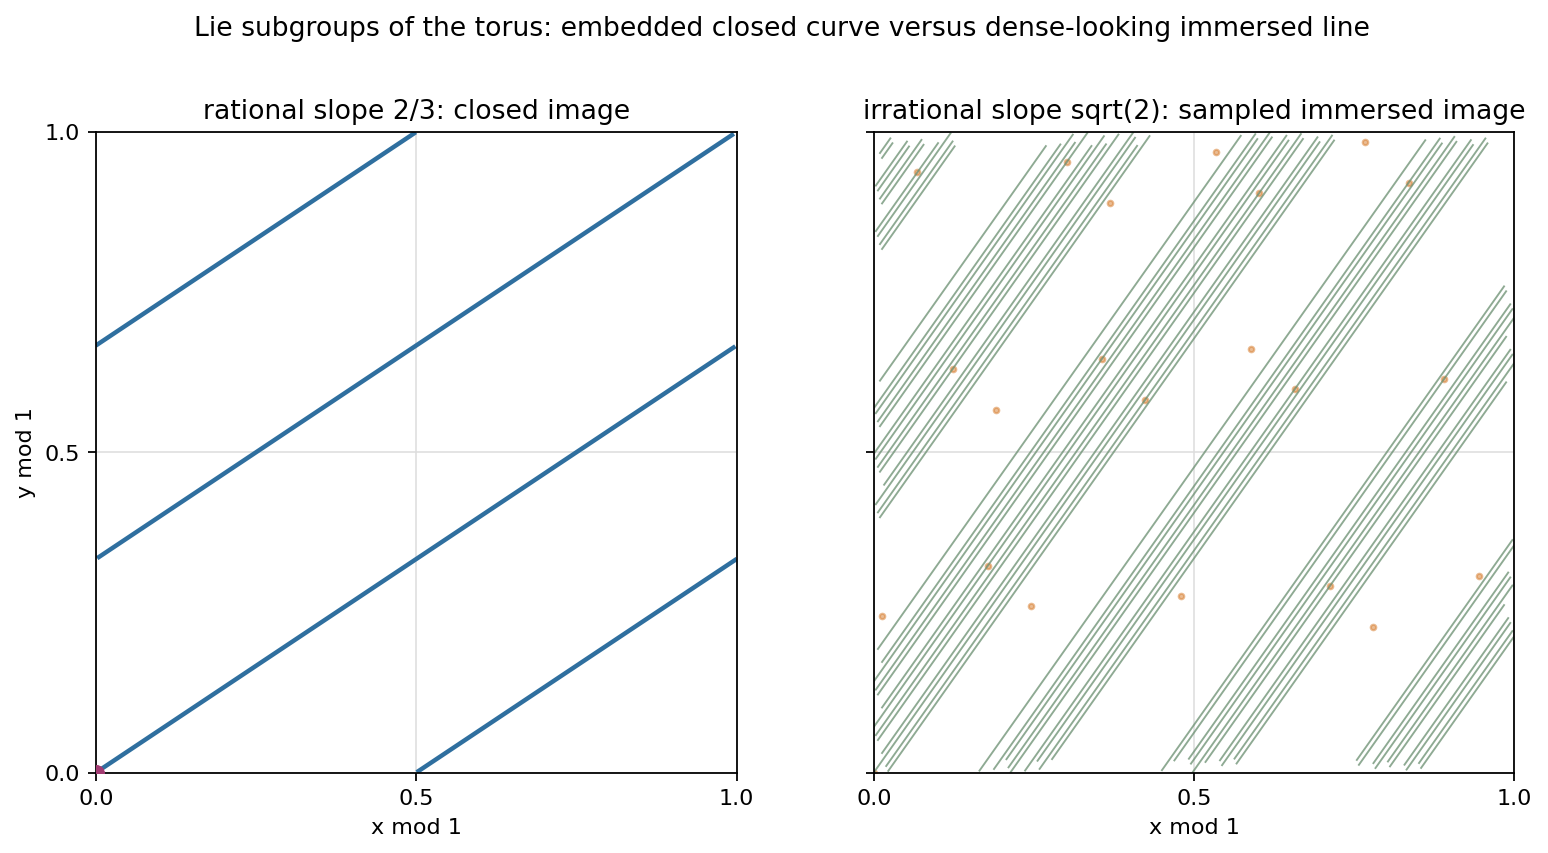

In [3]:
group_rows = [
    {"group": "GL(n,R)", "condition": "det(A) != 0", "dimension": "n^2", "route": "open subset of R^(n^2)"},
    {"group": "SL(n,R)", "condition": "det(A) = 1", "dimension": "n^2 - 1", "route": "regular determinant level set"},
    {"group": "O(n)", "condition": "A.T A = I", "dimension": "n(n-1)/2", "route": "regular level into symmetric matrices"},
    {"group": "SO(n)", "condition": "A in O(n), det(A)=1", "dimension": "n(n-1)/2", "route": "identity component of O(n)"},
    {"group": "U(n)", "condition": "A.conj().T A = I", "dimension": "n^2 real", "route": "Hermitian target; exercise variant"},
    {"group": "SU(n)", "condition": "unitary and det(A)=1", "dimension": "n^2 - 1 real", "route": "unitary plus determinant constraint"},
    {"group": "Sp variants", "condition": "preserve quaternionic or symplectic form", "dimension": "depends on model", "route": "choose target matching symmetry type"},
]
group_table_path = register(save_csv(group_rows, TABLES / "matrix-group-conditions.csv"))

def torus_segments(alpha, t_end, steps):
    t_values = np.linspace(0.0, t_end, steps)
    pts = np.column_stack((t_values % 1.0, (alpha * t_values) % 1.0))
    jumps = np.where(np.linalg.norm(np.diff(pts, axis=0), axis=1) > 0.55)[0]
    segments = []
    start = 0
    for jump in jumps:
        if jump + 1 - start > 1:
            segments.append(pts[start:jump + 1])
        start = jump + 1
    if len(pts) - start > 1:
        segments.append(pts[start:])
    return pts, segments

rational_pts, rational_segments = torus_segments(2 / 3, 3.0, 420)
irrational_pts, irrational_segments = torus_segments(math.sqrt(2), 55.0, 3400)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2), sharex=True, sharey=True)
for ax, title in zip(axes, ["rational slope 2/3: closed image", "irrational slope sqrt(2): sampled immersed image"]):
    ax.set_aspect("equal")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    ax.grid(True, color="#dddddd", linewidth=0.7)
    ax.set_title(title)
    ax.set_xlabel("x mod 1")
axes[0].set_ylabel("y mod 1")
for seg in rational_segments:
    axes[0].plot(seg[:, 0], seg[:, 1], color="#2f6f9f", linewidth=2.0)
axes[0].scatter(rational_pts[[0, -1], 0], rational_pts[[0, -1], 1], s=42, color="#a23b72", zorder=3)
for seg in irrational_segments[::2]:
    axes[1].plot(seg[:, 0], seg[:, 1], color="#6b8f71", linewidth=0.85, alpha=0.76)
axes[1].scatter(irrational_pts[::160, 0], irrational_pts[::160, 1], s=6, color="#d9853b", alpha=0.55)
fig.suptitle("Lie subgroups of the torus: embedded closed curve versus dense-looking immersed line", y=1.02)
torus_path = register(save_matplotlib(fig, FIGURES / "torus-irrational-line-subgroup.png"))
plt.close(fig)

bins = np.histogram2d(irrational_pts[:, 0], irrational_pts[:, 1], bins=24, range=[[0, 1], [0, 1]])[0]
torus_check_path = register(save_json(
    {
        "rational_slope": 2 / 3,
        "irrational_slope": math.sqrt(2),
        "rational_start_end_distance": float(np.linalg.norm(rational_pts[0] - rational_pts[-1])),
        "irrational_occupied_bins_24x24": int(np.count_nonzero(bins)),
        "irrational_coverage_fraction_24x24": float(np.count_nonzero(bins) / bins.size),
    },
    CHECKS / "torus-irrational-line-subgroup.json",
))
check_registry["rational_torus_line_closes"] = float(np.linalg.norm(rational_pts[0] - rational_pts[-1])) < 1e-12
check_registry["irrational_sample_has_broad_coverage"] = float(np.count_nonzero(bins) / bins.size) > 0.75

display(Markdown(rows_to_markdown(group_rows, ["group", "condition", "dimension", "route"])))
display_artifact(torus_path, width=820)


## The Matrix Exponential in `SO(2)`

Let `J = [[0,-1],[1,0]]`. The powers of `J` alternate between `I`, `J`, `-I`, and `-J`, so the exponential series reorganizes into sine and cosine terms. The curve `theta -> exp(theta J)` is a curve through the identity in `SO(2)`, and its initial velocity is `J`. This is the smallest nontrivial example where the chapter's slogan is visible: a tangent vector at the identity generates a group-valued curve.


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


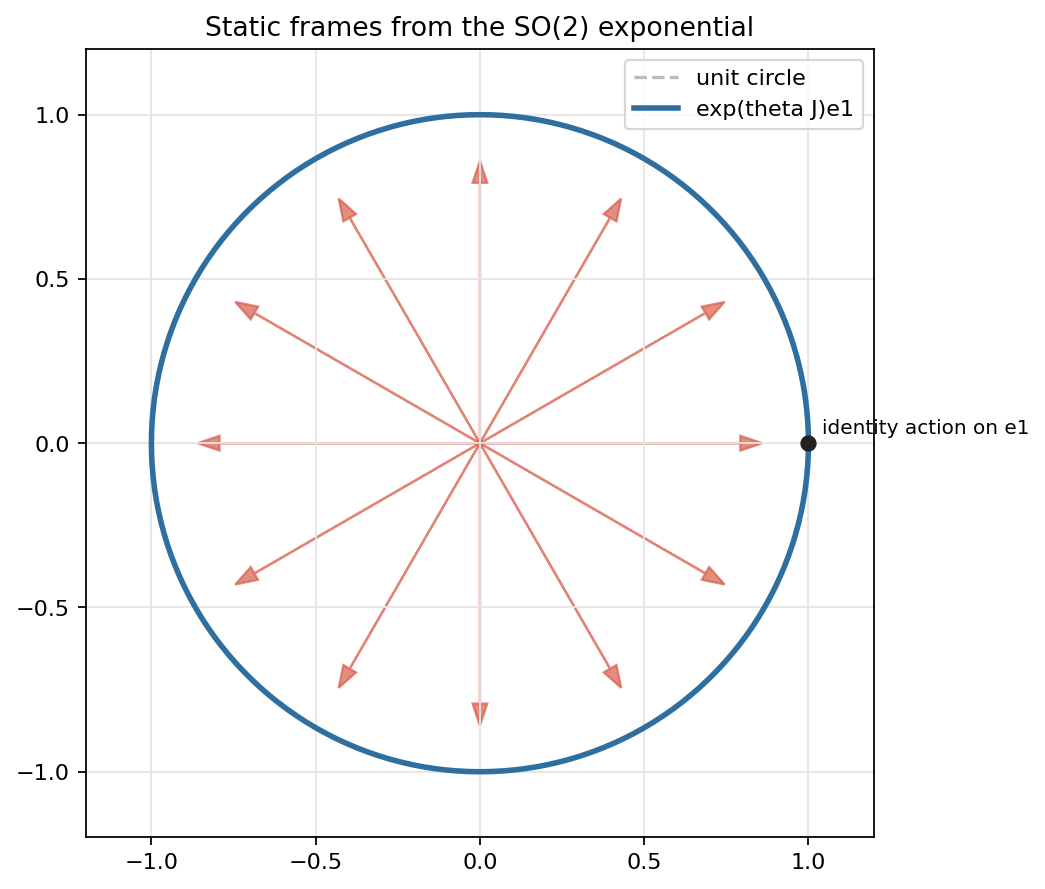

In [4]:
J = np.array([[0.0, -1.0], [1.0, 0.0]])
theta = np.linspace(0.0, 2 * np.pi, 181)
rotations = np.array([expm(t_value * J) for t_value in theta])
orbit = np.array([R @ np.array([1.0, 0.0]) for R in rotations])
unit_circle = np.column_stack((np.cos(theta), np.sin(theta)))

fig_plotly = go.Figure(
    data=[
        go.Scatter(x=unit_circle[:, 0], y=unit_circle[:, 1], mode="lines", name="unit circle", line={"color": "#999999", "dash": "dot"}),
        go.Scatter(x=orbit[:, 0], y=orbit[:, 1], mode="lines", name="exp(theta J) e1", line={"color": "#2f6f9f", "width": 3}),
        go.Scatter(x=[0, orbit[0, 0]], y=[0, orbit[0, 1]], mode="lines+markers", name="current vector", line={"color": "#d85c4a", "width": 4}),
    ],
    frames=[
        go.Frame(
            data=[
                go.Scatter(x=unit_circle[:, 0], y=unit_circle[:, 1]),
                go.Scatter(x=orbit[:, 0], y=orbit[:, 1]),
                go.Scatter(x=[0, orbit[k, 0]], y=[0, orbit[k, 1]]),
            ],
            name=str(k),
        )
        for k in range(0, len(theta), 6)
    ],
)
fig_plotly.update_layout(
    title="SO(2) exponential orbit: exp(theta J) acting on e1",
    xaxis={"scaleanchor": "y", "range": [-1.25, 1.25], "title": "x"},
    yaxis={"range": [-1.25, 1.25], "title": "y"},
    width=720,
    height=620,
    updatemenus=[{"type": "buttons", "buttons": [{"label": "play", "method": "animate", "args": [None, {"frame": {"duration": 80, "redraw": True}, "fromcurrent": True}]}]}],
)
so2_html_path = register(save_plotly_html(fig_plotly, HTML / "so2-exponential-orbit.html"))

fig, ax = plt.subplots(figsize=(6.6, 6.4))
ax.plot(unit_circle[:, 0], unit_circle[:, 1], color="#bbbbbb", linestyle="--", label="unit circle")
ax.plot(orbit[:, 0], orbit[:, 1], color="#2f6f9f", linewidth=2.5, label="exp(theta J)e1")
for angle in np.linspace(0, 2 * np.pi, 12, endpoint=False):
    v = expm(angle * J) @ np.array([1.0, 0.0])
    ax.arrow(0, 0, 0.86 * v[0], 0.86 * v[1], head_width=0.045, color="#d85c4a", length_includes_head=True, alpha=0.7)
ax.scatter([1], [0], color="#222222", s=40, zorder=4)
ax.text(1.04, 0.03, "identity action on e1", fontsize=9)
ax.set_aspect("equal")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.grid(True, color="#e5e5e5")
ax.set_title("Static frames from the SO(2) exponential")
ax.legend(loc="upper right")
so2_png_path = register(save_matplotlib(fig, FIGURES / "so2-exponential-orbit.png"))
plt.close(fig)

closed_form_residuals = []
orthogonality_residuals = []
det_residuals = []
for t_value, R in zip(theta, rotations):
    closed = np.array([[np.cos(t_value), -np.sin(t_value)], [np.sin(t_value), np.cos(t_value)]])
    closed_form_residuals.append(np.linalg.norm(R - closed))
    orthogonality_residuals.append(np.linalg.norm(R.T @ R - np.eye(2)))
    det_residuals.append(abs(np.linalg.det(R) - 1.0))
so2_check_path = register(save_json(
    {
        "generator": "J = [[0,-1],[1,0]]",
        "max_closed_form_residual": float(np.max(closed_form_residuals)),
        "max_orthogonality_residual": float(np.max(orthogonality_residuals)),
        "max_determinant_residual": float(np.max(det_residuals)),
        "initial_velocity_residual": float(np.linalg.norm((expm(1e-6 * J) - np.eye(2)) / 1e-6 - J)),
    },
    CHECKS / "so2-exponential-orbit.json",
))
check_registry["so2_closed_form"] = float(np.max(closed_form_residuals)) < 1e-12
check_registry["so2_stays_in_group"] = float(np.max(orthogonality_residuals)) < 1e-12 and float(np.max(det_residuals)) < 1e-12

display_artifact(so2_html_path, width=760, height=620)
display_artifact(so2_png_path, width=620)


## Trace, Determinant, and the Differential of `det`

The determinant is multiplicative, but its differential at the identity is additive: it is the trace. The matrix exponential is the bridge between those two facts. The identity `det(exp X) = exp(tr X)` says that exponentiating a matrix never leaves `GL(n,R)`, because the determinant is never zero. Differentiating the determinant along `t -> exp(tX)` at `t=0` gives `d(det)_I(X)=tr(X)`.


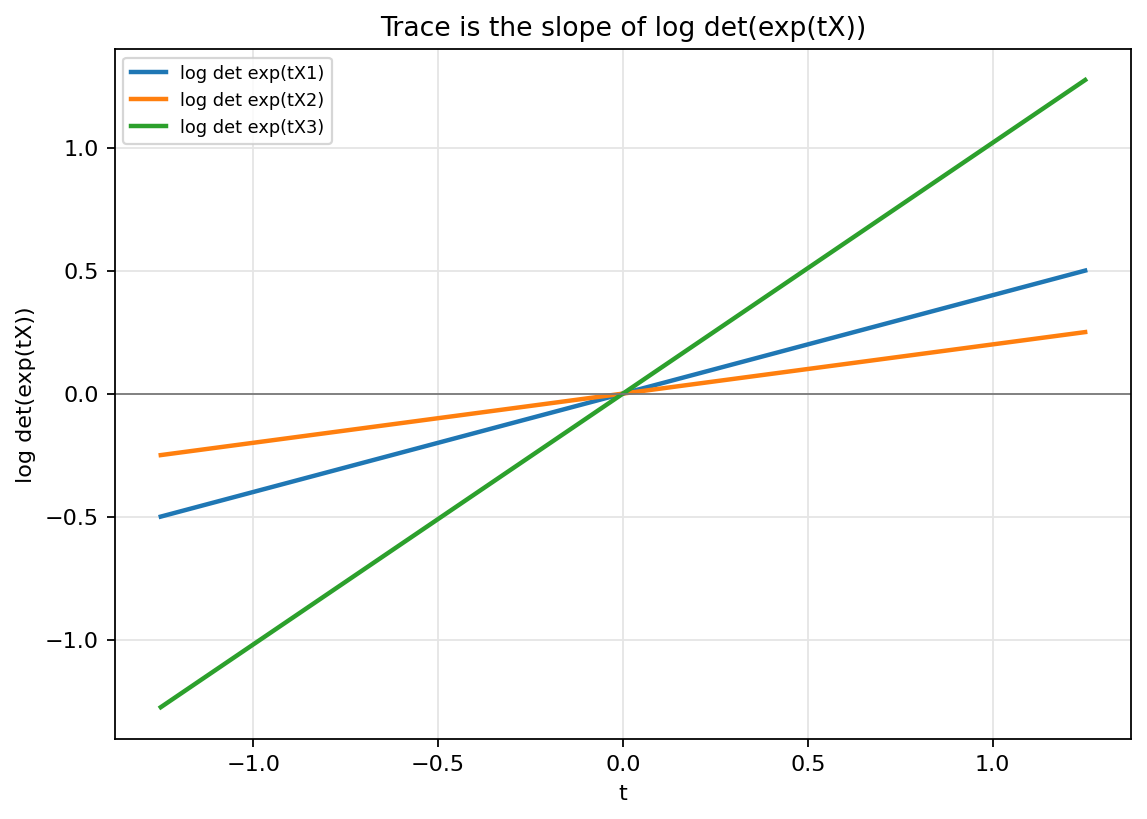

| sample | trace | max_abs_det_exp_residual |
| --- | --- | --- |
| X1 | 0.40000000 | 4.441e-16 |
| X2 | 0.20000000 | 4.441e-16 |
| X3 | 1.01980205 | 1.332e-15 |

In [5]:
t, x11, x12, x21, x22 = sp.symbols("t x11 x12 x21 x22", real=True)
Xsym = sp.Matrix([[x11, x12], [x21, x22]])
det_linearized = sp.diff((sp.eye(2) + t * Xsym).det(), t).subs(t, 0)
trace_sym = sp.trace(Xsym)
symbolic_det_differential_ok = sp.simplify(det_linearized - trace_sym) == 0

sample_matrices = [
    np.array([[0.2, -0.7, 0.4], [0.1, 0.3, -0.5], [0.6, 0.2, -0.1]]),
    np.array([[0.0, -1.0, 0.0], [1.0, 0.0, 0.25], [0.0, -0.1, 0.2]]),
    rng.normal(size=(3, 3)) / 3.0,
]
trace_rows = []
plot_ts = np.linspace(-1.25, 1.25, 80)
fig, ax = plt.subplots(figsize=(8.2, 5.6))
for idx, X in enumerate(sample_matrices, start=1):
    residuals = []
    log_dets = []
    line_values = []
    for tv in plot_ts:
        E = expm(tv * X)
        det_value = np.linalg.det(E)
        target = math.exp(tv * np.trace(X))
        residuals.append(abs(det_value - target))
        log_dets.append(math.log(abs(det_value)))
        line_values.append(tv * float(np.trace(X)))
    ax.plot(plot_ts, log_dets, linewidth=2, label=f"log det exp(tX{idx})")
    ax.plot(plot_ts, line_values, linestyle="--", linewidth=1, color=ax.lines[-1].get_color(), alpha=0.75)
    trace_rows.append({"sample": f"X{idx}", "trace": f"{float(np.trace(X)):.8f}", "max_abs_det_exp_residual": f"{max(residuals):.3e}"})
ax.axhline(0, color="#777777", linewidth=0.8)
ax.set_xlabel("t")
ax.set_ylabel("log det(exp(tX))")
ax.set_title("Trace is the slope of log det(exp(tX))")
ax.legend(fontsize=8)
ax.grid(True, color="#e5e5e5")
det_trace_fig_path = register(save_matplotlib(fig, FIGURES / "det-trace-exponential-check.png"))
plt.close(fig)

det_trace_table_path = register(save_csv(trace_rows, TABLES / "det-trace-exponential-check.csv"))
max_det_trace_residual = max(float(row["max_abs_det_exp_residual"]) for row in trace_rows)
det_trace_check_path = register(save_json(
    {
        "symbolic_d_det_identity": "d/dt det(I+tX)|_{t=0} = tr(X)",
        "symbolic_det_differential_ok": bool(symbolic_det_differential_ok),
        "det_linearized": str(det_linearized),
        "trace": str(trace_sym),
        "max_numeric_det_exp_residual": max_det_trace_residual,
    },
    CHECKS / "det-trace-exponential-check.json",
))
check_registry["det_differential_is_trace_symbolic"] = bool(symbolic_det_differential_ok)
check_registry["det_exp_trace_numeric"] = max_det_trace_residual < 1e-10

display_artifact(det_trace_fig_path, width=760)
display(Markdown(rows_to_markdown(trace_rows, ["sample", "trace", "max_abs_det_exp_residual"])))


## Tangent Spaces at the Identity: `SL` and `O`

A tangent vector is detected by differentiating a curve that stays inside the group. For `SL(n,R)`, a curve `c(t)` in the group satisfies `det(c(t))=1`; at `c(0)=I`, differentiating gives `tr(c'(0))=0`. For `O(n)`, a curve satisfies `c(t).T c(t)=I`; differentiating at the identity gives `X.T + X = 0`. These are the linearized versions of the group constraints.


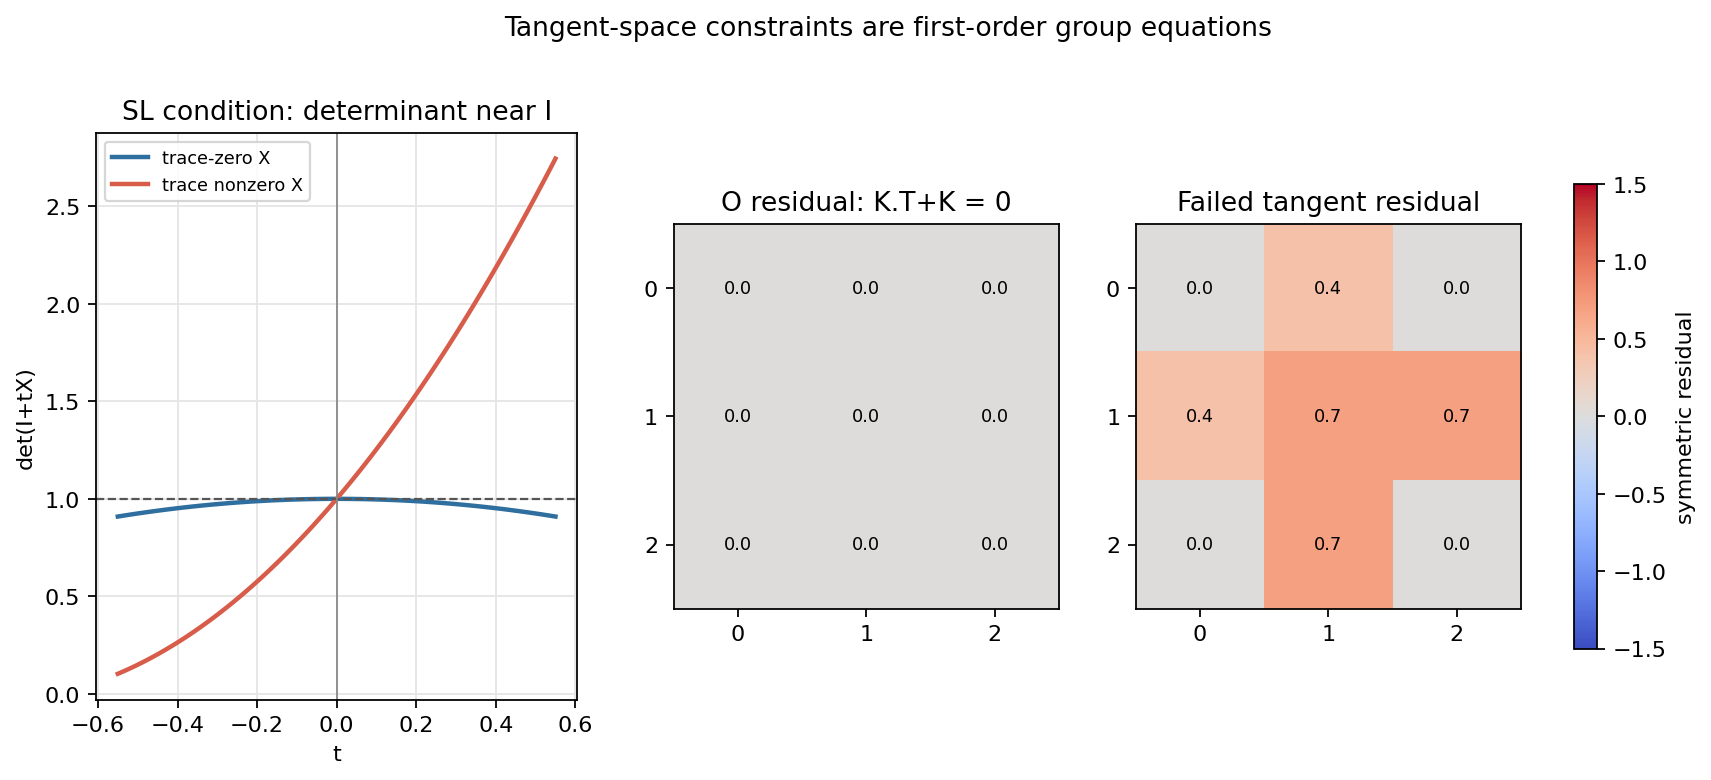

| group | identity_tangent_condition | sample_residual | dimension |
| --- | --- | --- | --- |
| SL(n,R) | tr(X)=0 | 0.000e+00 | n^2-1 |
| O(n) | X.T+X=0 | 0.000e+00 | n(n-1)/2 |

In [6]:
X_sl = np.array([[1.0, 2.0], [-0.35, -1.0]])
X_not_sl = np.array([[1.0, 0.25], [0.0, 1.4]])
small_t = np.linspace(-0.55, 0.55, 120)
det_sl = [np.linalg.det(np.eye(2) + tv * X_sl) for tv in small_t]
det_not_sl = [np.linalg.det(np.eye(2) + tv * X_not_sl) for tv in small_t]

K_o = np.array([[0.0, 1.2, -0.4], [-1.2, 0.0, 0.8], [0.4, -0.8, 0.0]])
K_not_o = np.array([[0.0, 1.2, -0.4], [-0.8, 0.35, 0.8], [0.4, -0.1, 0.0]])

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.6))
axes[0].plot(small_t, det_sl, label="trace-zero X", color="#2f6f9f", linewidth=2)
axes[0].plot(small_t, det_not_sl, label="trace nonzero X", color="#d85c4a", linewidth=2)
axes[0].axhline(1, color="#555555", linestyle="--", linewidth=1)
axes[0].axvline(0, color="#888888", linewidth=0.8)
axes[0].set_title("SL condition: determinant near I")
axes[0].set_xlabel("t")
axes[0].set_ylabel("det(I+tX)")
axes[0].legend(fontsize=8)
axes[0].grid(True, color="#e5e5e5")

im1 = axes[1].imshow(K_o.T + K_o, cmap="coolwarm", vmin=-1.5, vmax=1.5)
axes[1].set_title("O residual: K.T+K = 0")
axes[1].set_xticks(range(3))
axes[1].set_yticks(range(3))
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f"{(K_o.T + K_o)[i,j]:.1f}", ha="center", va="center", fontsize=8)

im2 = axes[2].imshow(K_not_o.T + K_not_o, cmap="coolwarm", vmin=-1.5, vmax=1.5)
axes[2].set_title("Failed tangent residual")
axes[2].set_xticks(range(3))
axes[2].set_yticks(range(3))
for i in range(3):
    for j in range(3):
        axes[2].text(j, i, f"{(K_not_o.T + K_not_o)[i,j]:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im2, ax=axes[1:], shrink=0.82, label="symmetric residual")
fig.suptitle("Tangent-space constraints are first-order group equations", y=1.04)
tangent_fig_path = register(save_matplotlib(fig, FIGURES / "tangent-conditions-sl-o.png"))
plt.close(fig)

tangent_rows = [
    {"group": "SL(n,R)", "identity_tangent_condition": "tr(X)=0", "sample_residual": f"{abs(np.trace(X_sl)):.3e}", "dimension": "n^2-1"},
    {"group": "O(n)", "identity_tangent_condition": "X.T+X=0", "sample_residual": f"{np.linalg.norm(K_o.T + K_o):.3e}", "dimension": "n(n-1)/2"},
]
tangent_table_path = register(save_csv(tangent_rows, TABLES / "tangent-conditions-sl-o.csv"))
tangent_check_path = register(save_json(
    {
        "trace_traceless_X": float(np.trace(X_sl)),
        "trace_nontraceless_X": float(np.trace(X_not_sl)),
        "skew_residual_K_o": float(np.linalg.norm(K_o.T + K_o)),
        "skew_residual_K_not_o": float(np.linalg.norm(K_not_o.T + K_not_o)),
    },
    CHECKS / "tangent-conditions-sl-o.json",
))
check_registry["sl_tangent_trace_zero"] = abs(np.trace(X_sl)) < 1e-12
check_registry["o_tangent_skew_symmetric"] = np.linalg.norm(K_o.T + K_o) < 1e-12
check_registry["failed_tangent_examples_detected"] = abs(np.trace(X_not_sl)) > 1e-3 and np.linalg.norm(K_not_o.T + K_not_o) > 1e-3

display_artifact(tangent_fig_path, width=900)
display(Markdown(rows_to_markdown(tangent_rows, ["group", "identity_tangent_condition", "sample_residual", "dimension"])))


## The Bracket on `gl(n,R)` is the Matrix Commutator

A left-invariant vector field generated by a matrix `A` has value `gA` at the matrix `g`. When the vector-field bracket is transported back to the identity, the result is the commutator `[A,B] = AB - BA`. The table below uses the standard `sl(2,R)` basis `H`, `E`, and `F`; its entries are matrix products, not memorized structure constants.


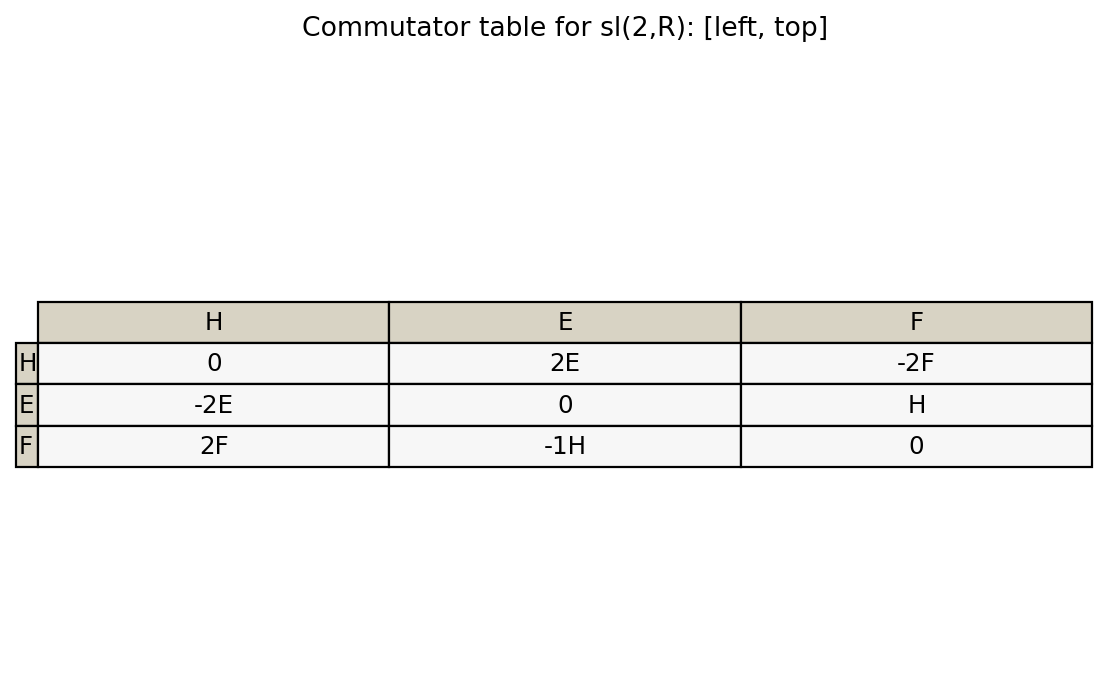

| left | right | commutator_coordinates |
| --- | --- | --- |
| H | H | 0 |
| H | E | 2E |
| H | F | -2F |
| E | H | -2E |
| E | E | 0 |
| E | F | H |
| F | H | 2F |
| F | E | -1H |
| F | F | 0 |

In [7]:
H = np.array([[1.0, 0.0], [0.0, -1.0]])
E = np.array([[0.0, 1.0], [0.0, 0.0]])
F = np.array([[0.0, 0.0], [1.0, 0.0]])
basis = {"H": H, "E": E, "F": F}

def sl2_coordinates(M):
    return np.array([0.5 * (M[0, 0] - M[1, 1]), M[0, 1], M[1, 0]])

def coord_label(coords):
    names = ["H", "E", "F"]
    pieces = []
    for value, name in zip(coords, names):
        rounded = int(round(value)) if abs(value - round(value)) < 1e-12 else value
        if abs(float(rounded)) > 1e-12:
            pieces.append(f"{rounded:g}{name}" if rounded != 1 else name)
    return " + ".join(pieces).replace("+ -", "- ") if pieces else "0"

bracket_rows = []
bracket_matrix = []
for left_name, left in basis.items():
    row = []
    for right_name, right in basis.items():
        label = coord_label(sl2_coordinates(commutator(left, right)))
        row.append(label)
        bracket_rows.append({"left": left_name, "right": right_name, "commutator_coordinates": label})
    bracket_matrix.append(row)

fig, ax = plt.subplots(figsize=(6.8, 4.8))
ax.axis("off")
table = ax.table(cellText=bracket_matrix, rowLabels=list(basis), colLabels=list(basis), loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.25, 1.55)
for (row, col), cell in table.get_celld().items():
    cell.set_facecolor("#d8d3c4" if row == 0 or col == -1 else "#f7f7f7")
ax.set_title("Commutator table for sl(2,R): [left, top]", pad=24)
bracket_fig_path = register(save_matplotlib(fig, FIGURES / "bracket-commutator-table.png"))
plt.close(fig)

A, B, C = H + 2 * E - F, 0.5 * H - 3 * E + F, -H + E + 4 * F
jacobi = commutator(A, commutator(B, C)) + commutator(B, commutator(C, A)) + commutator(C, commutator(A, B))
trace_closure_residual = max(abs(np.trace(commutator(L, R))) for L in basis.values() for R in basis.values())
Kx = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, -1.0], [0.0, 1.0, 0.0]])
Ky = np.array([[0.0, 0.0, 1.0], [0.0, 0.0, 0.0], [-1.0, 0.0, 0.0]])
Kz = np.array([[0.0, -1.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, 0.0]])
skew_closure_residual = max(np.linalg.norm(commutator(L, R).T + commutator(L, R)) for L in [Kx, Ky, Kz] for R in [Kx, Ky, Kz])

bracket_table_path = register(save_csv(bracket_rows, TABLES / "bracket-commutator-sl2.csv"))
bracket_check_path = register(save_json(
    {
        "basis_order": list(basis),
        "table": bracket_rows,
        "jacobi_residual": float(np.linalg.norm(jacobi)),
        "trace_closure_residual_sl2": float(trace_closure_residual),
        "skew_closure_residual_o3": float(skew_closure_residual),
    },
    CHECKS / "bracket-commutator-table.json",
))
check_registry["commutator_jacobi"] = float(np.linalg.norm(jacobi)) < 1e-12
check_registry["sl2_commutator_closes"] = float(trace_closure_residual) < 1e-12
check_registry["o3_commutator_closes"] = float(skew_closure_residual) < 1e-12

display_artifact(bracket_fig_path, width=620)
display(Markdown(rows_to_markdown(bracket_rows, ["left", "right", "commutator_coordinates"])))


## Left-Invariant Field Transport

A single tangent vector at the identity determines a left-invariant vector field. For `GL(n,R)`, the formula is especially direct: `B` at `I` gives field value `gB` at `g`. The plot uses the positive diagonal subgroup of `GL(2,R)`, written as diagonal entries `(x,y)`. If the identity tangent vector is `B = diag(a,b)`, then the left-invariant field is `(a x, b y)`. The arrows are not constant in coordinates, but they are constant after translating back to the identity.


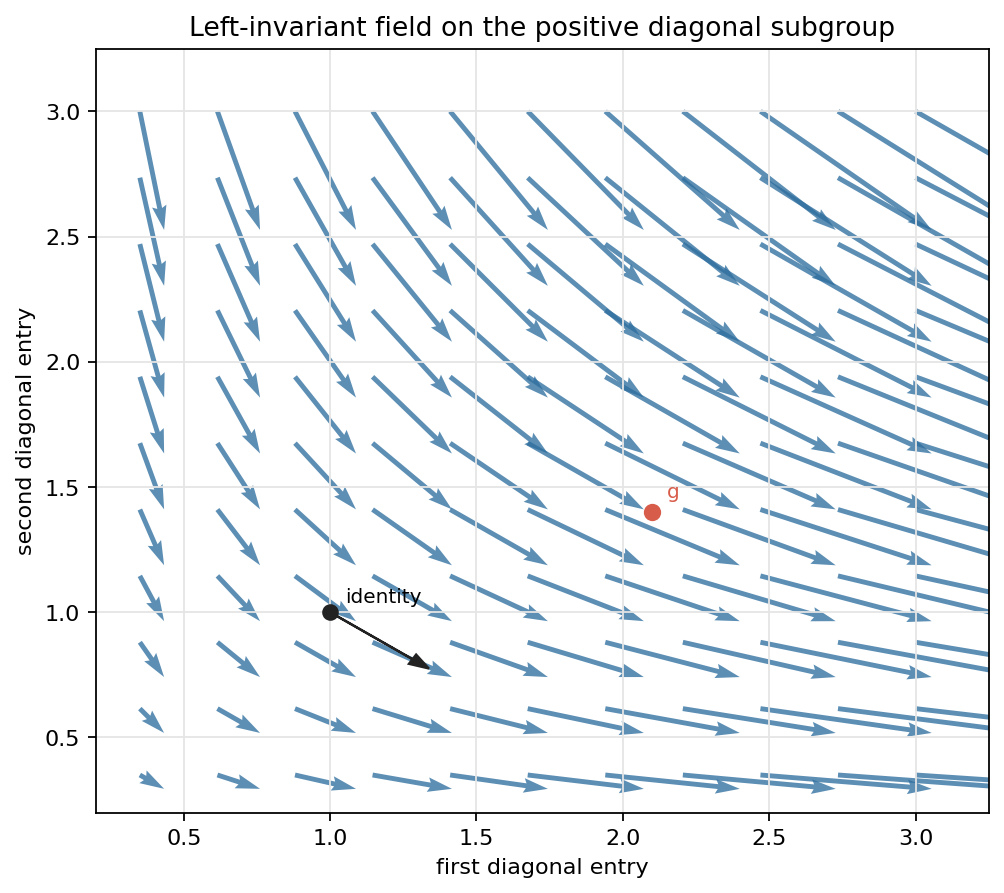

In [8]:
a, b = 0.45, -0.30
x_vals = np.linspace(0.35, 3.0, 11)
y_vals = np.linspace(0.35, 3.0, 11)
Xgrid, Ygrid = np.meshgrid(x_vals, y_vals)
U = a * Xgrid
V = b * Ygrid

fig, ax = plt.subplots(figsize=(7.2, 6.2))
ax.quiver(Xgrid, Ygrid, U, V, angles="xy", scale_units="xy", scale=1.9, color="#2f6f9f", alpha=0.78)
ax.scatter([1], [1], color="#222222", s=42, zorder=4)
ax.text(1.05, 1.04, "identity", fontsize=9)
ax.scatter([2.1], [1.4], color="#d85c4a", s=46, zorder=4)
ax.text(2.15, 1.46, "g", fontsize=9, color="#d85c4a")
ax.arrow(1, 1, a * 0.75, b * 0.75, head_width=0.045, color="#222222", length_includes_head=True)
ax.set_xlim(0.2, 3.25)
ax.set_ylim(0.2, 3.25)
ax.set_xlabel("first diagonal entry")
ax.set_ylabel("second diagonal entry")
ax.set_title("Left-invariant field on the positive diagonal subgroup")
ax.grid(True, color="#e5e5e5")
left_field_path = register(save_matplotlib(fig, FIGURES / "left-invariant-field-transport.png"))
plt.close(fig)

Bdiag = np.diag([a, b])
g = np.diag([2.1, 1.4])
h = np.diag([1.3, 0.75])
left_side = g @ (h @ Bdiag)
right_side = (g @ h) @ Bdiag
left_transport_residual = float(np.linalg.norm(left_side - right_side))
left_field_check_path = register(save_json(
    {
        "subgroup": "positive diagonal matrices in GL(2,R)",
        "generator_diagonal": [a, b],
        "formula": "X_g = gB",
        "left_transport_residual": left_transport_residual,
        "sample_g": np.diag(g).tolist(),
        "sample_h": np.diag(h).tolist(),
    },
    CHECKS / "left-invariant-field-transport.json",
))
check_registry["left_invariant_transport"] = left_transport_residual < 1e-12

display_artifact(left_field_path, width=680)


## Homomorphism Differentials Preserve Brackets

A Lie group homomorphism sends the identity to the identity, so it has a differential between tangent spaces at the identities. The chapter's structural result is that this differential is a Lie algebra homomorphism. Two checks make this concrete. The determinant homomorphism `det: GL(n,R) -> R^x` has differential `tr`, and bracket preservation says `tr([A,B]) = 0`. The inner automorphism `h -> g h g^-1` has differential `A -> g A g^-1`, and bracket preservation says conjugation carries commutators to commutators.


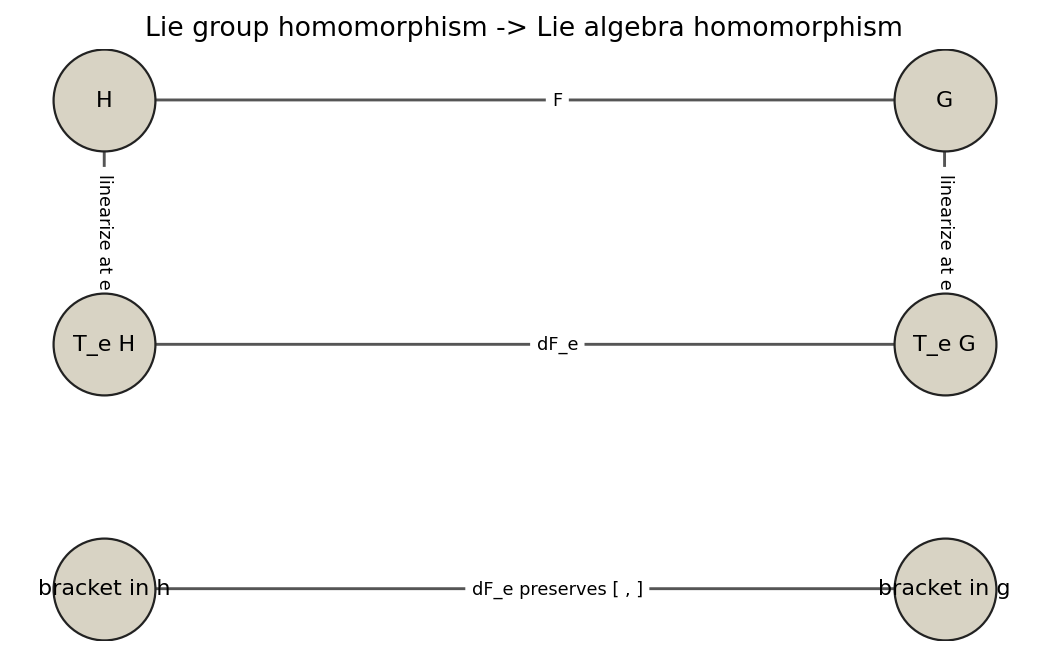

| homomorphism | differential | bracket_check | residual |
| --- | --- | --- | --- |
| det: GL(2,R)->R^x | trace | tr([A,B])=0 | 0.000e+00 |
| inner automorphism | A -> gAg^-1 | Ad_g([A,B])=[Ad_g A,Ad_g B] | 5.829e-16 |

In [9]:
A = np.array([[0.2, 1.1], [-0.4, 0.7]])
B = np.array([[1.0, -0.3], [0.6, -0.2]])
g_auto = np.array([[1.4, 0.35], [0.2, 1.1]])
g_inv = np.linalg.inv(g_auto)
AdA = g_auto @ A @ g_inv
AdB = g_auto @ B @ g_inv
AdBracket = g_auto @ commutator(A, B) @ g_inv
BracketAd = commutator(AdA, AdB)

det_hom_residual = float(abs(np.trace(commutator(A, B))))
inner_auto_residual = float(np.linalg.norm(AdBracket - BracketAd))

square = nx.DiGraph()
square.add_edge("H", "G", label="F")
square.add_edge("T_e H", "T_e G", label="dF_e")
square.add_edge("H", "T_e H", label="linearize at e")
square.add_edge("G", "T_e G", label="linearize at e")
square.add_edge("bracket in h", "bracket in g", label="dF_e preserves [ , ]")
pos = {"H": (0, 1.0), "G": (2.6, 1.0), "T_e H": (0, 0.0), "T_e G": (2.6, 0.0), "bracket in h": (0, -1.0), "bracket in g": (2.6, -1.0)}
fig, ax = plt.subplots(figsize=(8.2, 4.8))
nx.draw_networkx_nodes(square, pos, ax=ax, node_color="#d8d3c4", edgecolors="#222222", node_size=2100)
nx.draw_networkx_labels(square, pos, ax=ax, font_size=10)
nx.draw_networkx_edges(square, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=16, width=1.3, edge_color="#555555")
nx.draw_networkx_edge_labels(square, pos, edge_labels=nx.get_edge_attributes(square, "label"), ax=ax, font_size=8, label_pos=0.54)
ax.set_title("Lie group homomorphism -> Lie algebra homomorphism")
ax.axis("off")
hom_square_path = register(save_matplotlib(fig, FIGURES / "homomorphism-differential-square.png"))
plt.close(fig)

hom_rows = [
    {"homomorphism": "det: GL(2,R)->R^x", "differential": "trace", "bracket_check": "tr([A,B])=0", "residual": f"{det_hom_residual:.3e}"},
    {"homomorphism": "inner automorphism", "differential": "A -> gAg^-1", "bracket_check": "Ad_g([A,B])=[Ad_g A,Ad_g B]", "residual": f"{inner_auto_residual:.3e}"},
]
hom_table_path = register(save_csv(hom_rows, TABLES / "homomorphism-differential-checks.csv"))
hom_check_path = register(save_json(
    {
        "det_homomorphism_trace_commutator_residual": det_hom_residual,
        "inner_automorphism_bracket_residual": inner_auto_residual,
        "sample_g_determinant": float(np.linalg.det(g_auto)),
    },
    CHECKS / "homomorphism-differential-checks.json",
))
check_registry["det_differential_preserves_bracket"] = det_hom_residual < 1e-12
check_registry["inner_automorphism_preserves_bracket"] = inner_auto_residual < 1e-12

display_artifact(hom_square_path, width=760)
display(Markdown(rows_to_markdown(hom_rows, ["homomorphism", "differential", "bracket_check", "residual"])))


## Applied Lab: Break the Tangent Condition

The trace-zero condition for `T_I SL(2,R)` is easy to say but more useful when it has a failure mode. Start with a trace-zero matrix `X` and compare it with `X + epsilon I`. The exponential of `tX` stays in determinant one because `tr X = 0`; the perturbed curve has determinant `exp(2 epsilon t)` and immediately leaves `SL(2,R)` unless `epsilon=0`.


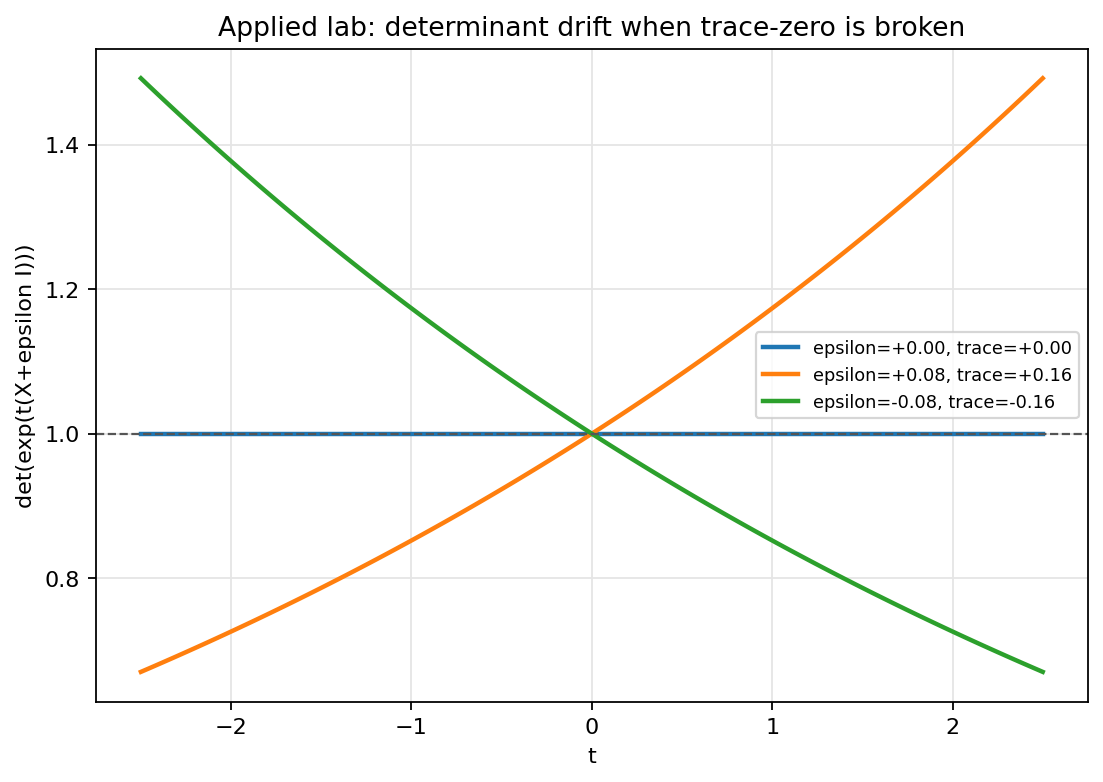

| epsilon | trace | max_drift_from_SL |
| --- | --- | --- |
| +0.00 | +0.00 | 9.992e-16 |
| +0.08 | +0.16 | 4.918e-01 |
| -0.08 | -0.16 | 4.918e-01 |

In [10]:
X_lab = np.array([[0.4, 1.0], [-0.6, -0.4]])
epsilons = [0.0, 0.08, -0.08]
ts_lab = np.linspace(-2.5, 2.5, 120)
lab_rows = []
fig, ax = plt.subplots(figsize=(8.0, 5.3))
for eps in epsilons:
    X_eps = X_lab + eps * np.eye(2)
    det_values = [float(np.linalg.det(expm(tv * X_eps))) for tv in ts_lab]
    target_values = [math.exp(tv * np.trace(X_eps)) for tv in ts_lab]
    residual = max(abs(actual - target) for actual, target in zip(det_values, target_values))
    max_drift = max(abs(value - 1.0) for value in det_values)
    ax.plot(ts_lab, det_values, linewidth=2, label=f"epsilon={eps:+.2f}, trace={np.trace(X_eps):+.2f}")
    lab_rows.append({"epsilon": eps, "trace": float(np.trace(X_eps)), "max_det_exp_identity_residual": residual, "max_drift_from_SL": max_drift})
ax.axhline(1, color="#555555", linestyle="--", linewidth=1)
ax.set_xlabel("t")
ax.set_ylabel("det(exp(t(X+epsilon I)))")
ax.set_title("Applied lab: determinant drift when trace-zero is broken")
ax.legend(fontsize=8)
ax.grid(True, color="#e5e5e5")
lab_fig_path = register(save_matplotlib(fig, FIGURES / "sl2-tangent-lab.png"))
plt.close(fig)

lab_csv_path = register(save_csv(
    [{k: (f"{v:.8f}" if isinstance(v, float) else v) for k, v in row.items()} for row in lab_rows],
    TABLES / "sl2-tangent-lab.csv",
))
lab_check_path = register(save_json({"rows": lab_rows}, CHECKS / "sl2-tangent-lab.json"))
check_registry["trace_zero_lab_stays_in_SL"] = lab_rows[0]["max_drift_from_SL"] < 1e-12
check_registry["trace_perturbation_lab_drifts"] = lab_rows[1]["max_drift_from_SL"] > 0.1 and lab_rows[2]["max_drift_from_SL"] > 0.1

display_artifact(lab_fig_path, width=760)
display(Markdown(rows_to_markdown(
    [{"epsilon": f"{row['epsilon']:+.2f}", "trace": f"{row['trace']:+.2f}", "max_drift_from_SL": f"{row['max_drift_from_SL']:.3e}"} for row in lab_rows],
    ["epsilon", "trace", "max_drift_from_SL"],
)))


## Takeaways

- A Lie group is more than a group with coordinates: its multiplication and inverse must be smooth maps.
- Matrix groups become manageable when their defining equations are translated into level-set or closed-subgroup checks.
- The matrix exponential supplies group-valued curves with prescribed initial velocity; in `SO(2)` this is literally rotation by angle.
- The determinant and trace identity explains why `d(det)_I` is trace and why trace-zero matrices form `T_I SL(n,R)`.
- The orthogonal constraint linearizes to skew-symmetry, so `T_I O(n)` is the space of skew-symmetric matrices.
- Left-invariant vector fields identify the tangent space at the identity with a Lie algebra; for `gl(n,R)`, the bracket is the commutator.
- Differentials of Lie group homomorphisms preserve brackets, which is the first functorial bridge from Lie groups to Lie algebras.


## Final Sanity Checks

The final cell checks that the artifacts exist, are nonempty, and record the chapter's core invariants: `SO(2)` membership, determinant-trace identity, tangent-space constraints, commutator closure, left-invariant transport, and bracket preservation by homomorphism differentials.


In [11]:
# final_sanity
final_sanity_paths = list(dict.fromkeys(all_artifacts))
assert_artifacts(final_sanity_paths, min_bytes=80)

failed_checks = [name for name, passed in check_registry.items() if not bool(passed)]
if failed_checks:
    raise AssertionError(f"Failed chapter checks: {failed_checks}")

final_summary = {
    "unit": UNIT_TITLE,
    "source_span_printed": "164-189",
    "pdf_pages_read": "183-208",
    "artifact_count": len(final_sanity_paths),
    "checks": {name: bool(value) for name, value in sorted(check_registry.items())},
}
final_summary_path = save_json(final_summary, CHECKS / "final-sanity-summary.json")
assert_artifacts([final_summary_path], min_bytes=80)
print(json.dumps(final_summary, indent=2, sort_keys=True))
print(f"final_sanity passed for {UNIT_TITLE} with {len(final_sanity_paths) + 1} artifacts/check files")


{
  "artifact_count": 26,
  "checks": {
    "commutator_jacobi": true,
    "det_differential_is_trace_symbolic": true,
    "det_differential_preserves_bracket": true,
    "det_exp_trace_numeric": true,
    "failed_tangent_examples_detected": true,
    "inner_automorphism_preserves_bracket": true,
    "irrational_sample_has_broad_coverage": true,
    "left_invariant_transport": true,
    "o3_commutator_closes": true,
    "o_tangent_skew_symmetric": true,
    "rational_torus_line_closes": true,
    "sl2_commutator_closes": true,
    "sl_tangent_trace_zero": true,
    "so2_closed_form": true,
    "so2_stays_in_group": true,
    "storyboard_connected": true,
    "trace_perturbation_lab_drifts": true,
    "trace_zero_lab_stays_in_SL": true
  },
  "pdf_pages_read": "183-208",
  "source_span_printed": "164-189",
  "unit": "Lie Groups and Lie Algebras"
}
final_sanity passed for Lie Groups and Lie Algebras with 27 artifacts/check files
